# Genetic Algorithm(neuroevolution) for Unit Placement

## Импорт необходимых библиотек и подготовка среды

In [1]:
import torch
import torch.nn as nn
import numpy as np
import copy
import random
import matplotlib.pyplot as plt
import socket
from IPython.display import clear_output  

POP_SIZE = 15 
MUTATION_RATE = 0.05   
INPUT_SIZE = 102           
HIDDEN1 = 64               
HIDDEN2 = 32               
OUTPUT_SIZE = 225      

HOST = '127.0.0.1'      
PORT = 5005

## Нейронная сеть

In [2]:
class BattleNet(nn.Module):
    def __init__(self, input_size=102, hidden1=64, hidden2=32, output_size=225):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)
        
        for param in self.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.relu(x)
        x = self.fc3(x)
        return torch.sigmoid(x)
    
    def get_weights(self):
        weights = []
        for param in self.parameters():
            weights.extend(param.numpy().flatten())
        return np.array(weights)
    
    def set_weights(self, weights):
        start = 0
        for param in self.parameters():
            size = param.numel()
            new_param = weights[start:start+size].reshape(param.shape)
            param.copy_(torch.from_numpy(new_param))
            start += size

В данном разделе определяется структура **полносвязной нейронной сети** (Multi-Layer Perceptron, MLP). Сеть обучается методом **нейроэволюции**, поэтому стандартный механизм обратного распространения ошибки (*backpropagation*) полностью отключен.

### 1. Математическая модель

Сеть выполняет последовательное нелинейное преобразование входного вектора состояния среды $\mathbf{x}$ в выходной вектор предиктов $\mathbf{y}$ через систему скрытых слоев.

#### **Структура входных данных**


Входной вектор $\mathbf{x} \in \mathbb{R}^{102}$ формируется путем **объединения** признаков среды:
$$\mathbf{x} = [s_1, s_2, \dots, s_{100}, b, r]$$
Где:
* $s_{1 \dots 100}$ — состояние клеток игрового поля ($0$ — пусто, $1$ — препятствие);
* $b$ — текущий бюджет эликсира;
* $r$ — порядковый номер игрового раунда.


#### **Процесс прямого прохода (Forward Pass)**

Вычисления в слоях производятся по следующим формулам:

1. **Первый скрытый слой ($\mathbf{h_1}$):**
   $$\mathbf{h_1} = \text{ReLU}(W_1 \mathbf{x} + \mathbf{b_1})$$
   Где $W_1$ — матрица весов размера $64 \times 102$, а $\mathbf{b_1}$ — вектор смещений (bias).

2. **Второй скрытый слой ($\mathbf{h_2}$):**
   $$\mathbf{h_2} = \text{ReLU}(W_2 \mathbf{h_1} + \mathbf{b_2})$$
   Где $W_2$ — матрица весов размера $32 \times 64$.

3. **Выходной слой ($\mathbf{y}$):**
   $$\mathbf{y} = \sigma(W_3 \mathbf{h_2} + \mathbf{b_3})$$
   Используется логистическая функция (сигмоида): $\sigma(z) = \frac{1}{1 + e^{-z}}$, которая масштабирует значения в диапазон $(0, 1)$, интерпретируемый как «уверенность» сети в выборе позиции.

### 2. Особенности реализации для генетического алгоритма


* **Заморозка градиентов:** Так как обучение происходит через эволюцию весов, свойство `requires_grad` для всех параметров установлено в `False`. Это отключает механизм автоматического дифференцирования PyTorch, что существенно снижает нагрузку на оперативную память и ускоряет выполнение итераций:
  $$\frac{\partial \mathcal{L}}{\partial \theta} = 0$$

* **Генотип особи:** Полный набор весов и смещений сети $\theta = \{W, \mathbf{b}\}$ извлекается в виде одномерного массива. Это позволяет операторам мутации и кроссовера напрямую корректировать структуру связей агента, изменяя его поведение без использования градиентных методов.

* **Функция активации ReLU:** Использование $f(z) = \max(0, z)$ в скрытых слоях обеспечивает избирательную активацию нейронов, помогая сети игнорировать малозначимые входные данные (например, пустые клетки поля).

### 3. Техническая спецификация

| Слой | Тип | Размерность | Функция активации |
| :--- | :--- | :--- | :--- |
| **Input** | Linear | $102 \to 64$ | ReLU |
| **Hidden** | Linear | $64 \to 32$ | ReLU |
| **Output** | Linear | $32 \to 225$ | Sigmoid |

### Декодер

In [3]:
def decode_output(probabilities, budget, state_vector):
    UNIT_COSTS = {
        1: {1: 3, 2: 6, 3: 9},   # Knight
        2: {1: 2, 2: 4, 3: 6},   # Archer
        3: {1: 4, 2: 8, 3: 12}   # Mage
    }

    layout = ["0:0"] * 25
    current_budget = budget
    occupied_cells = set()
    
    # Первые 25 элементов вектора — наша половина поля
    our_half_grid = state_vector[0:25] 
    blocked_cells = {i for i, cell_val in enumerate(our_half_grid) if cell_val == -1 or cell_val == 1}

    all_options = []
    combinations = [
        (1, 1), (1, 2), (1, 3), 
        (2, 1), (2, 2), (2, 3), 
        (3, 1), (3, 2), (3, 3)  
    ]

    for combo_idx, (u_type, u_level) in enumerate(combinations):
        start_idx = combo_idx * 25
        chunk = probabilities[start_idx : start_idx + 25]
        
        for cell_idx, confidence in enumerate(chunk):
            all_options.append({
                'cell': cell_idx,
                'type': u_type,
                'level': u_level,
                'conf': confidence,
                'cost': UNIT_COSTS[u_type][u_level]
            })

    # Сортируем по уверенности сети (сначала самые уверенные предикты)
    all_options.sort(key=lambda x: x['conf'], reverse=True)

    for opt in all_options:
        if opt['cell'] in occupied_cells or opt['cell'] in blocked_cells:
            continue
        
        if opt['conf'] < 0.2: 
            continue

        if current_budget >= opt['cost']:
            layout[opt['cell']] = f"{opt['type']}:{opt['level']}"
            current_budget -= opt['cost']
            occupied_cells.add(opt['cell'])

    return ",".join(layout)

## Генетический алгоритм

In [4]:
## Генетический алгоритм
class GAManager:
    def __init__(self, pop_size=15, mutation_power=0.05):
        self.pop_size = pop_size
        self.mutation_power = mutation_power
        self.population = [BattleNet() for _ in range(pop_size)]
        self.fitness_history = []

    def evolve(self, fitness_scores):
        import json
        
        # 1. Считаем генетическое разнообразие (std по весам всей популяции)
        all_weights = [bot.get_weights() for bot in self.population]
        diversity = float(np.std(all_weights))

        # 2. Считаем Win Rate врагов (сколько ботов набрали больше 2.0 фитнеса благодаря бонусу победы)
        wins = sum(1 for score in fitness_scores if score > 2.0)
        win_rate = (wins / self.pop_size) * 100.0

        # 3. Сохраняем расширенную статистику в историю (в оперативной памяти)
        self.fitness_history.append({
            'max': float(max(fitness_scores)), 
            'avg': float(np.mean(fitness_scores)),
            'min': float(min(fitness_scores)),
            'win_rate': win_rate,
            'diversity': diversity
        })

        # 4. Автоматическая запись на диск в изолированный файл ga_metrics.json
        try:
            with open('ga_metrics.json', 'w', encoding='utf-8') as f:
                json.dump(self.fitness_history, f, indent=4, ensure_ascii=False)
        except Exception as e:
            print(f"  [!] Ошибка при записи ga_metrics.json на диск: {e}")

        # 5. Эволюционный отбор и создание нового поколения
        new_population = []
        selection_scores = list(fitness_scores) 

        # Элитизм: защищаем чемпиона через deepcopy от любых мутаций
        best_idx = np.argmax(selection_scores)
        champion = self.population[best_idx]
        new_population.append(copy.deepcopy(champion))

        # 5.1 АВТОМАТИЧЕСКОЕ СОХРАНЕНИЕ МОЗГОВ ЧЕМПИОНА НА ДИСК
        try:
            torch.save(champion.state_dict(), 'best_ga_model.pth')
        except Exception as e:
            print(f"  [!] Ошибка при сохранении весов best_ga_model.pth: {e}")

        # Заполняем остаток популяции потомками
        while len(new_population) < self.pop_size:
            parent1, parent2 = self._select_parents(selection_scores)
            
            child_weights = self._crossover(parent1, parent2)
            child_weights = self._mutate(child_weights)
            
            child = BattleNet()
            child.set_weights(child_weights)
            new_population.append(child)
            
        self.population = new_population
    
    def _select_parents(self, fitness_scores):
        def tournament():
            subset_indices = random.sample(range(self.pop_size), 4)
            best_in_subset = max(subset_indices, key=lambda i: fitness_scores[i])
            return self.population[best_in_subset]
        
        parent1 = tournament()
        parent2 = tournament()
        
        attempts = 0
        while parent1 is parent2 and attempts < 10:
            parent2 = tournament()
            attempts += 1
            
        return parent1, parent2
    
    def _crossover(self, p1, p2):
        w1 = p1.get_weights()
        w2 = p2.get_weights()
        mask = np.random.randint(0, 2, size=w1.shape).astype(bool)
        return np.where(mask, w1, w2)
    
    def _mutate(self, weights):
        mutation = np.random.normal(0, self.mutation_power, size=weights.shape)
        return weights + mutation

Класс `GAManager` реализует логику искусственного отбора для оптимизации весовых коэффициентов нейронных сетей. Алгоритм имитирует процесс биологической эволюции, итерируя через поколения для поиска глобального максимума функции приспособленности (Fitness).

### 1. Компоненты эволюционного процесса

Для обеспечения стабильного роста результатов и сохранения разнообразия в популяции используются следующие механизмы:

* **Элитизм (Elitism):** Стратегия, при которой особь с максимальным показателем Fitness (чемпион) переходит в следующее поколение без изменений. Это гарантирует, что достигнутый рекорд не будет потерян из-за деструктивной мутации.
* **Турнирная селекция (Tournament Selection):** Метод выбора родителей, при котором из популяции случайно выбирается группа особей (в данном случае 4), и победителем становится лучшая из них. Это позволяет сохранять генетическое разнообразие и давать шанс менее приспособленным особям, что предотвращает преждевременную сходимость алгоритма.
* **Равномерное скрещивание (Uniform Crossover):** Процесс создания потомка, при котором каждый «ген» (весовой коэффициент) выбирается случайно от одного из двух родителей с равной вероятностью:
    $$w_{child} = \begin{cases} w_{parent1}, & p < 0.5 \\ w_{parent2}, & p \geq 0.5 \end{cases}$$
* **Нормальная мутация (Gaussian Mutation):** Внесение случайного шума в веса потомка. Мы используем нормальное распределение с центром в $0$ и стандартным отклонением, задаваемым параметром `mutation_power`:
    $$w_{new} = w_{old} + \mathcal{N}(0, \sigma^2)$$

### 2. Математическая оценка и мониторинг

После каждой итерации (поколения) алгоритм фиксирует ключевые метрики для анализа эффективности обучения:
* **Max Fitness:** Максимальный урон, нанесенный лучшей конфигурацией.
* **Average Fitness:** Средний урон по всей популяции, показывающий общий уровень «интеллекта» поколения.

### 3. Технические особенности реализации

| Метод | Функция | Описание |
| :--- | :--- | :--- |
| `evolve` | Цикл развития | Отвечает за логирование статистики и формирование нового поколения. |
| `_select_parents` | Турнир | Обеспечивает выбор двух уникальных родительских структур. |
| `_crossover` | Рекомбинация | Создает маску для смешивания весовых матриц родителей. |
| `_mutate` | Модификация | Применяет случайные правки к весам для поиска новых стратегий. |

## Сервер и отрисовка

In [5]:
def plot_live_evolution(history):
    if not history:
        return
    
    gen_idx = len(history) - 1
    max_val = history[-1]['max']
    avg_val = history[-1]['avg']

    print(f"\n=== ОБНОВЛЕНИЕ ГРАФИКА: ПОКОЛЕНИЕ {gen_idx} ===")
    print(f"Лучший результат (Max Fitness): {max_val:.2f}")
    print(f"Средний результат (Avg Fitness): {avg_val:.2f}\n")

    generations = range(len(history))
    max_fitness = [h['max'] for h in history]
    avg_fitness = [h['avg'] for h in history]

    plt.figure(figsize=(10, 5))
    plt.plot(generations, max_fitness, label='Max Fitness', color='#2ca02c', marker='o', markersize=4)
    plt.plot(generations, avg_fitness, label='Avg Fitness', color='#1f77b4', linestyle='--')
    
    plt.title(f'Прогресс нейроэволюции (Поколение {gen_idx})', fontsize=14)
    plt.xlabel('Поколение')
    plt.ylabel('Fitness (Delta HP)')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

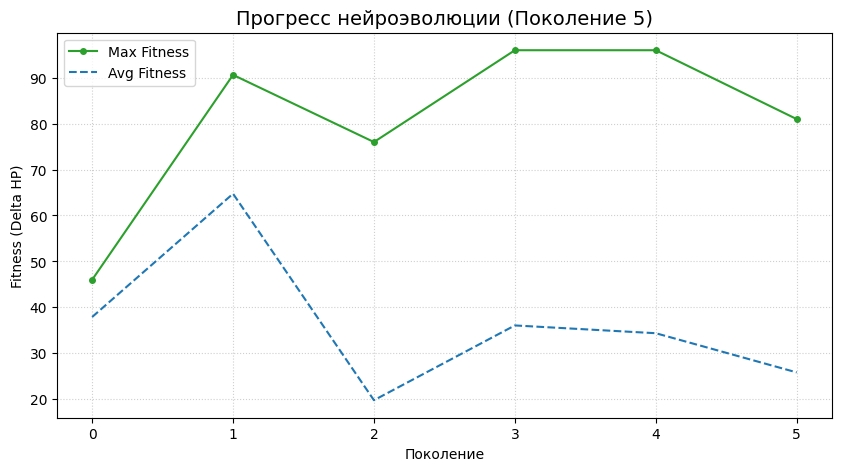


--- [Поколение 6]: Ожидание 15 подключений ---


In [ ]:
ga = GAManager(pop_size=POP_SIZE, mutation_power=MUTATION_RATE)

def run_evolution_cycle():
    generation = 0
    print(f"ГА Сервер успешно запущен на {HOST}:{PORT}. Ожидаем лавину ботов из Unity...")
    
    try:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as server_socket:
            server_socket.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            server_socket.bind((HOST, PORT))
            server_socket.listen(POP_SIZE)
            
            while True:
                fitness_scores = []
                print(f"\n--- [Поколение {generation}]: Ожидание {POP_SIZE} подключений ---")
                
                for i in range(POP_SIZE):
                    conn, addr = server_socket.accept()
                    with conn:
                        try:
                            # Ожидаем данные от UnityConnector
                            raw_data = conn.recv(4096).decode().strip()
                            if not raw_data:
                                print(f"  [!] Бот {i+1}: Пустой пакет. Штраф.")
                                fitness_scores.append(-500.0) 
                                continue
                                
                            parts = raw_data.split('|')
                            if len(parts) < 3:
                                print(f"  [!] Бот {i+1}: Битая строка данных. Штраф.")
                                fitness_scores.append(-500.0)
                                continue

                            budget = float(parts[0])
                            last_fitness = float(parts[1])
                            state_vector = np.fromstring(parts[2], sep=',')
                            
                            fitness_scores.append(last_fitness)
                            
                            # Прогоняем состояние через сетку текущего бота
                            current_brain = ga.population[i]
                            with torch.no_grad():
                                # Конвертируем numpy-массив в тензор один раз здесь
                                state_tensor = torch.FloatTensor(state_vector)
                                probabilities = current_brain(state_tensor).numpy()
                            
                            # Декодируем вероятности в строку расстановки
                            layout_response = decode_output(probabilities, budget, state_vector)
                            
                            # Отправляем ответ обратно в Unity
                            conn.sendall(layout_response.encode())
                            print(f"  [OK] Бот {i+1}/{POP_SIZE} обсчитан. Fitness: {last_fitness:.2f}")
                            
                        except Exception as e:
                            print(f"  [X] Ошибка при обработке бота {i+1}: {e}")
                            fitness_scores.append(-500.0)

                print(f"\n--> Все боты собраны. Запускаем эволюционный отбор...")
                
                if len(fitness_scores) == POP_SIZE:
                    ga.evolve(fitness_scores)
                    
                    plt.close('all')
                    clear_output(wait=True)
                    plot_live_evolution(ga.fitness_history)
                    
                    generation += 1
                else:
                    print(f"Ошибка синхронизации: получено {len(fitness_scores)} результатов вместо {POP_SIZE}.")

    except KeyboardInterrupt:
        print("\nСервер остановлен пользователем.")
    except Exception as e:
        print(f"\nКритический сбой сервера: {e}")

# Поехали!
run_evolution_cycle()

In [31]:
def plot_final_dashboard(history):
    if not history:
        print("История пуста! Нечего рисовать.")
        return
        
    generations = range(len(history))
    max_fit = [h['max'] for h in history]
    avg_fit = [h['avg'] for h in history]
    min_fit = [h['min'] for h in history]
    win_rates = [h['win_rate'] for h in history]
    diversities = [h['diversity'] for h in history]

    # Создаем сетку из двух графиков: верхний и нижний
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # --- ГРАФИК 1: Эволюционный коридор фитнеса ---
    ax1.plot(generations, max_fit, label='Лучший бот (Max)', color='#2ca02c', linewidth=2, marker='o', markersize=3)
    ax1.plot(generations, avg_fit, label='Среднее по популяции (Avg)', color='#1f77b4', linestyle='--', linewidth=2)
    ax1.plot(generations, min_fit, label='Худший бот (Min)', color='#d62728', linestyle=':', alpha=0.7)
    
    # Красивая заливка (коридор) между лучшим и худшим результатом
    ax1.fill_between(generations, min_fit, max_fit, color='#1f77b4', alpha=0.1, label='Разброс популяции')
    
    ax1.set_title('Анализ сходимости генетического алгоритма (Фитнес)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Значение Fitness', fontsize=12)
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # --- ГРАФИК 2: Результативность и Разнообразие ---
    # Левая ось для Win Rate
    color = '#ff7f0e'
    ax2.set_xlabel('Поколение', fontsize=12)
    ax2.set_ylabel('Win Rate врагов (%)', color=color, fontsize=12)
    line1 = ax2.plot(generations, win_rates, color=color, linewidth=2, label='Win Rate (%)', marker='s', markersize=3)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(-5, 105)

    # Создаем вторую (правую) ось для Генетического разнообразия
    ax3 = ax2.twinx()  
    color = '#9467bd'
    ax3.set_ylabel('Разнообразие генотипа (Std Весов)', color=color, fontsize=12)
    line2 = ax3.plot(generations, diversities, color=color, linestyle='-.', linewidth=2, label='Diversity (Genotype)')
    ax3.tick_params(axis='y', labelcolor=color)

    # Собираем легенду для графика с двумя осями
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='lower right')
    
    ax2.set_title('Динамика винрейта и генетического разнообразия', fontsize=14, fontweight='bold')
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Вызов графика (запускать после завершения обучения)
plot_final_dashboard(ga.fitness_history)

История пуста! Нечего рисовать.
